In [87]:
import torch as T
import numpy as np
import tqdm
from matplotlib import pyplot as plt

device = T.device('cpu')

In [88]:
import PIL

horizon = 32

img = np.array(PIL.Image.open('cat.png').resize((horizon,horizon)))
logdensity = T.from_numpy(np.log(1+ img)).flatten().float()

In [89]:
ndim = 2

n_hid = 256
n_layers = 2

detailed_balance = False
uniform_pb = True

def make_mlp(l, act=T.nn.LeakyReLU(), tail=[]):
    return T.nn.Sequential(*(sum(
        [[T.nn.Linear(i, o)] + ([act] if n < len(l)-2 else [])
         for n, (i, o) in enumerate(zip(l, l[1:]))], []) + tail))

def log_reward(x):
    # ax = abs(x / (horizon-1) * 2 - 1)
    # return ((ax > 0.5).prod(-1) * 0.5 + ((ax < 0.8) * (ax > 0.6)).prod(-1) * 2 + 1e-1).log()
    x_ = x @ (horizon ** T.arange(ndim)).float()
    return logdensity[x_.long()]

j = T.zeros((horizon,)*ndim+(ndim,))
for i in range(ndim):
    jj = T.linspace(0,horizon-1,horizon)
    for _ in range(i): jj = jj.unsqueeze(1)
    j[...,i] = jj

truelr = log_reward(j)
print('total reward', truelr.view(-1).logsumexp(0))
true_dist = truelr.flatten().softmax(0).cpu().numpy()

total reward tensor(11.8279)


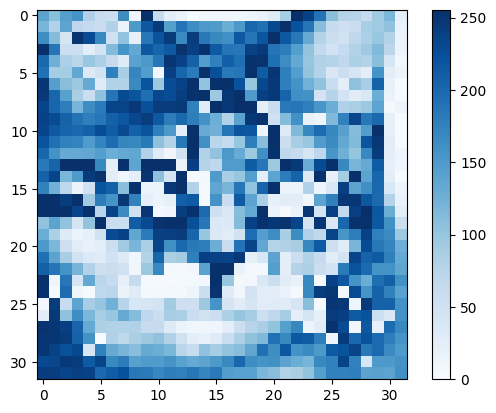

In [90]:
plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
plt.colorbar()

In [91]:
def toin(z):
    return T.nn.functional.one_hot(z, horizon).view(z.shape[0],-1).float()

def modeled_density(model):
    with T.no_grad():
        m = T.zeros((horizon,horizon))
        f = T.zeros((horizon,horizon))
        f[0,0] = 1
        for i in range(horizon):
            zs = T.zeros((horizon,2)).long()
            zs[:,0] = i
            zs[:,1] = T.arange(horizon)
            logits = model(toin(zs))[...,:3]
            edge_mask = T.cat([ (zs==horizon-1).float(), T.zeros((horizon,1), device=device) ], 1) 
            probs = ( logits - 100000000000*edge_mask ).softmax(1)
            for j in range(horizon):
                m[i,j] += f[i,j] * probs[j,2]
                if i<horizon-1: f[i+1,j] += f[i,j] * probs[j,0]
                if j<horizon-1: f[i,j+1] += f[i,j] * probs[j,1]
    return m

# Train without re-sampling

In [92]:
# Seed
np.random.seed(0)
T.manual_seed(0)

Z = T.zeros((1,)).to(device)
if detailed_balance:
    model = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt = T.optim.Adam([ {'params':model.parameters(), 'lr':0.001} ])
else:
    model = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt = T.optim.Adam([ {'params':model.parameters(), 'lr':0.001}, {'params':[Z], 'lr':0.1} ])
    Z.requires_grad_()


  0%|          | 0/1000 [00:00<?, ?it/s]

 10%|▉         | 97/1000 [00:03<00:35, 25.21it/s]

loss = 2.5594450956583024
Reverse KL = 0.2851613759994507
Forward KL = 0.24109919369220734


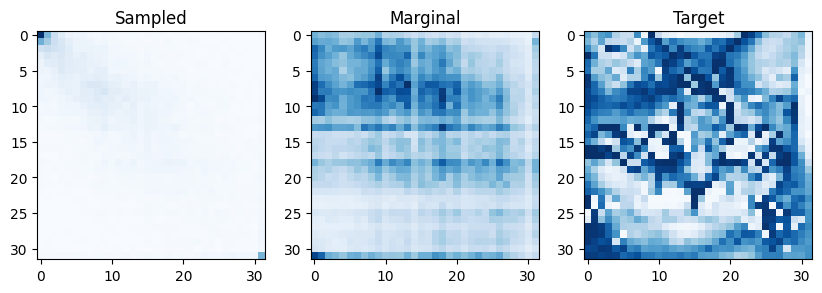

 20%|█▉        | 197/1000 [00:08<00:35, 22.54it/s]

loss = 0.5688504213094712
Reverse KL = 0.15859419107437134
Forward KL = 0.14102700352668762


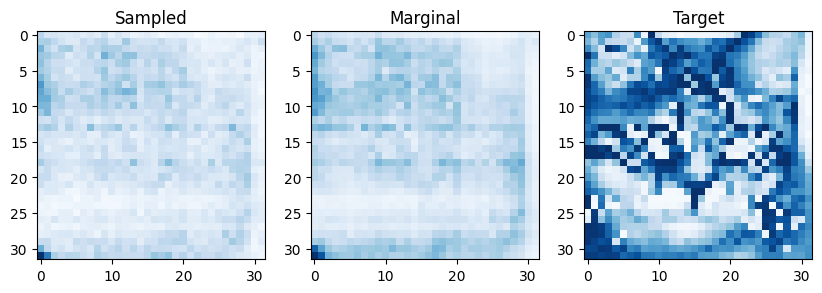

 30%|██▉       | 299/1000 [00:13<00:37, 18.70it/s]

loss = 0.32300274550914765
Reverse KL = 0.09353257715702057
Forward KL = 0.09154222905635834


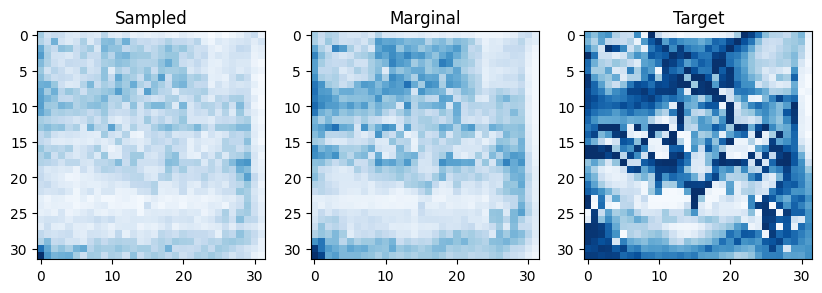

 40%|███▉      | 398/1000 [00:17<00:29, 20.15it/s]

loss = 0.1762468671798706
Reverse KL = 0.04671945795416832
Forward KL = 0.04880579933524132


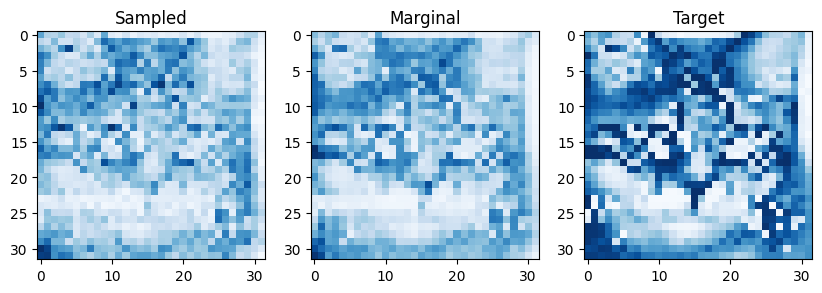

 50%|████▉     | 499/1000 [00:22<00:24, 20.33it/s]

loss = 0.0862842384725809
Reverse KL = 0.023494265973567963
Forward KL = 0.022962378337979317


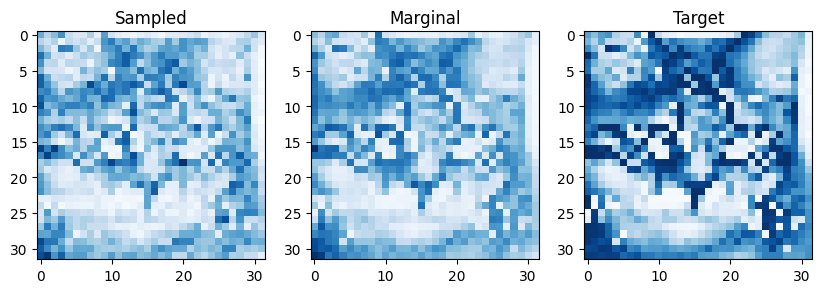

 60%|█████▉    | 599/1000 [00:27<00:16, 24.76it/s]

loss = 0.04469745436683297
Reverse KL = 0.011737639084458351
Forward KL = 0.011386457830667496


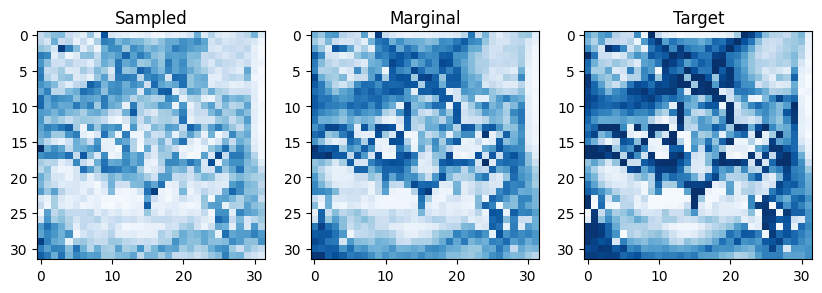

 70%|██████▉   | 697/1000 [00:31<00:13, 22.64it/s]

loss = 0.024286258006468414
Reverse KL = 0.006919462233781815
Forward KL = 0.006284711416810751


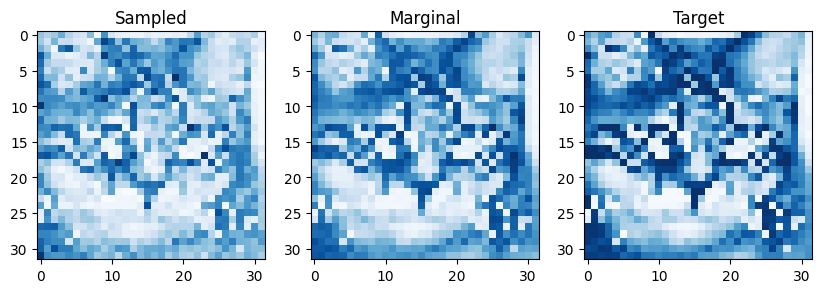

 80%|███████▉  | 799/1000 [00:36<00:11, 17.04it/s]

loss = 0.01366063023917377
Reverse KL = 0.0031479415483772755
Forward KL = 0.002788043348118663


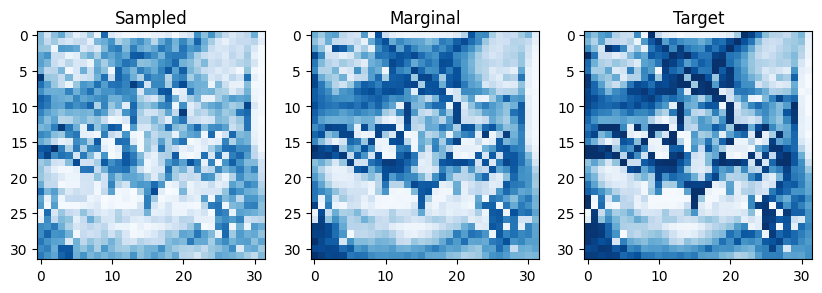

 90%|████████▉ | 897/1000 [00:41<00:05, 20.20it/s]

loss = 0.007268811443354934
Reverse KL = 0.002175630535930395
Forward KL = 0.0018788868328556418


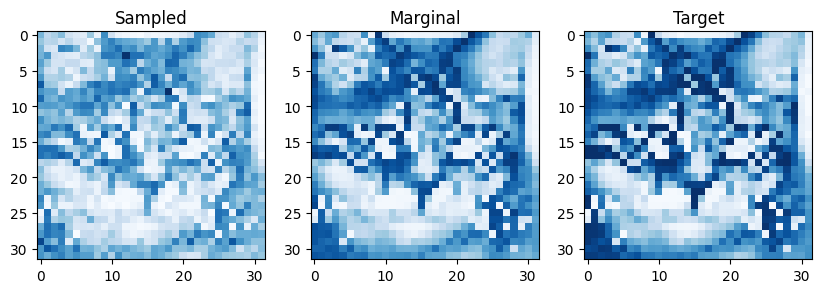

100%|█████████▉| 997/1000 [00:45<00:00, 25.12it/s]

loss = 0.0051156794105190785
Reverse KL = 0.0013103062519803643
Forward KL = 0.0011713216081261635


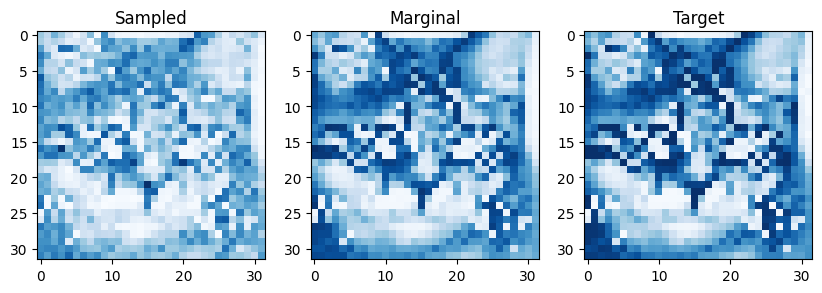

100%|██████████| 1000/1000 [00:46<00:00, 21.72it/s]


In [ ]:
losses = []
all_visited = []
resample = False
resample_every = -1

traj_len_history = []
weights_history = []

bs = 256
iter = 1000
T.set_grad_enabled(True)
for it in tqdm.trange(1, iter + 1):
    opt.zero_grad()
    
    z = T.zeros((bs, ndim), dtype=T.long).to(device)
    done = T.full((bs,), False, dtype=T.bool).to(device)
        
    action = None
    
    logf = T.zeros((ndim*horizon+1, bs)).to(device)
    logpf = T.zeros((ndim*horizon, bs)).to(device)
    logpb = T.zeros((ndim*horizon, bs)).to(device)
    
    i = 0
    while T.any(~done):
        
        pred = model(toin(z[~done]))

        edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # ended = (z[~done]==horizon-1).any(1).float()
        # ended_repeat = ended.unsqueeze(1).repeat(1,ndim)
        # edge_mask = T.cat([ ended_repeat, T.zeros(((~done).sum(),1), device=device) ], 1)

        logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        init_edge_mask = (z[~done]== 0).float()
        back_logits = ( (0 if uniform_pb else 1)*pred[...,ndim+1:2*ndim+1] - 1000000000*init_edge_mask).log_softmax(1)  # Need to check
        
        log_flow = pred[...,2*ndim+1]
        # if i>0 or detailed_balance: 
        #     logf[i,~done] = log_flow + log_reward(z[~done].float())  # DB with using reward information at every step
        # else: logf[i,~done] += Z
        logf[i,~done] = log_reward(z[~done].float()) - logits[:,ndim]
        
        if action is not None:
            logpb[i-1,~done] = back_logits.gather(1, action[action!=ndim].unsqueeze(1)).squeeze(1)

        # if resample and resample_every > 0 and i % resample_every == 0:
        #     cum_iw = - ( logf[0]+logpf.sum(0)-logf[i]-logpb.sum(0) )[~done]
        #     # weights = cum_iw.softmax(0).clamp(min=1./((~done).sum())**1.5)
        #     weights = cum_iw.softmax(0).clamp(max=1./((~done).sum())**1.5)
        #     sample = T.distributions.Categorical(weights).sample(((~done).sum(),))
        #     z[~done] = z[~done][sample]
        #     logf[:,~done] = logf[:,~done][:,sample]
        #     logpf[:,~done] = logpf[:,~done][:,sample]
        #     logpb[:,~done] = logpb[:,~done][:,sample]
        #     logits = logits[sample]

        # if T.all(done): break
        # # todo: avoid recomputing
        # pred = model(toin(z[~done]))
        # edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        exp_weight= 0.
        temp = 1
        sample_ins_probs = (1-exp_weight)*(logits/temp).softmax(1) + exp_weight*(1-edge_mask) / (1-edge_mask+0.0000001).sum(1).unsqueeze(1)
        
        action = sample_ins_probs.multinomial(1)
        logpf[i,~done] = logits.gather(1, action).squeeze(1)

        with T.no_grad():
            terminate = (action==ndim).squeeze(1)

            done[~done] |= terminate
            logf[i+1:,done] = log_reward(z[done].float())  

        with T.no_grad():
            z[~done] = z[~done].scatter_add(1, action[~terminate], T.ones(action[~terminate].shape, dtype=T.long, device=device))

        
        i += 1

    for x in z:
        state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
        all_visited.append(state)

    # z_save = z.clone()
    # if resample:
    #     err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) )
    #     # iw = err
    #     iw =  err + (err**2).log()
    #     weights = iw.softmax(0)#.clamp(max=1./bs**1.5)
    #     sample = T.distributions.Categorical(weights).sample((bs,))
    #     z = z[sample]
    #     logf = logf[:,sample]
    #     logpf = logpf[:,sample]
    #     logpb = logpb[:,sample]
    
    if detailed_balance:
        lens = z.sum(1)+1
        loss = (logf[:-1]+logpf-logf[1:]-logpb).pow(2).sum()/lens.sum() 
    else:
        weights = T.ones(bs).to(device)
        if resample and i % resample_every == 0:
            err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) ).detach()
            weights = err.softmax(0) * bs

        loss = (weights * (logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0)).pow(2)).sum()/bs
        
    loss.backward()

    opt.step()

    losses.append(loss.item())

    if it%100==0: 
        print('loss =', np.array(losses[-100:]).mean())#, 'Z =', logf[0,0].item())
        emp_dist = np.bincount(all_visited[-100*bs:], minlength=len(true_dist)).astype(float)
        emp_dist /= emp_dist.sum()
        md = modeled_density(model).T
        mdsm = md.flatten().log().log_softmax(0)
        truesm = truelr.flatten().log_softmax(0)
        print('Reverse KL =', -(mdsm.exp() * (truesm-mdsm)).sum().item())
        print('Forward KL =', -(truesm.exp() * (mdsm-truesm)).sum().item())
        plt.figure(figsize=(10,3))
        plt.subplot(1,3,1);plt.title('Sampled')
        plt.imshow(emp_dist.reshape(horizon,horizon), cmap='Blues', vmin=0)
        plt.subplot(1,3,2);plt.title('Marginal')
        plt.imshow(md, cmap='Blues', vmin=0)
        plt.subplot(1,3,3);plt.title('Target')
        plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
        plt.show()

# Train with resampling

In [112]:
np.random.seed(0)
T.manual_seed(0)

Z_resampled = T.zeros((1,)).to(device)
if detailed_balance:
    model_resampled = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt_resampled = T.optim.Adam([ {'params':model_resampled.parameters(), 'lr':0.001} ])
else:
    model_resampled = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt_resampled = T.optim.Adam([ {'params':model_resampled.parameters(), 'lr':0.001}, {'params':[Z_resampled], 'lr':0.1} ])
    Z_resampled.requires_grad_()

 10%|▉         | 99/1000 [00:03<00:37, 24.34it/s]

loss = 2.6020917600393294
Reverse KL = 0.27560287714004517
Forward KL = 0.22412098944187164


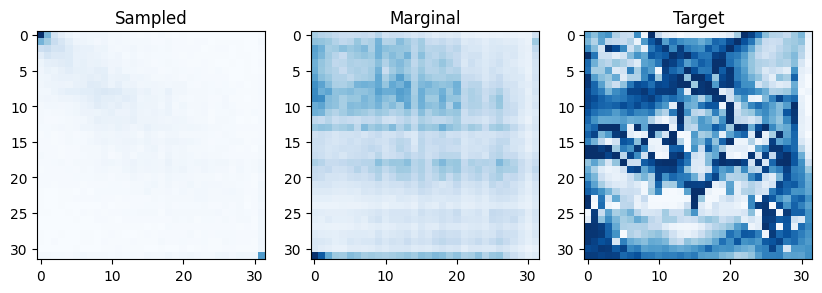

 20%|█▉        | 198/1000 [00:07<00:32, 24.71it/s]

loss = 0.5393733015656471
Reverse KL = 0.15961912274360657
Forward KL = 0.13866636157035828


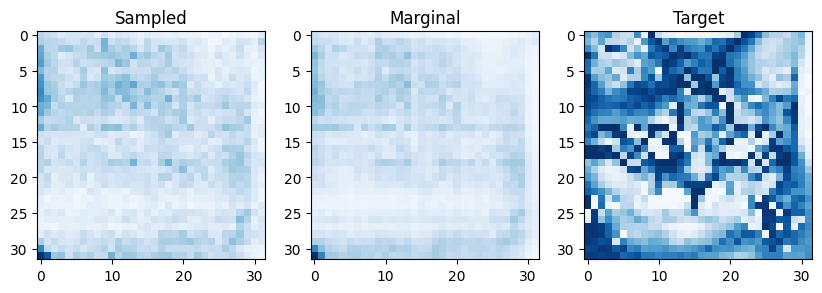

 30%|██▉       | 297/1000 [00:12<00:31, 22.64it/s]

loss = 0.3273675811290741
Reverse KL = 0.09227771311998367
Forward KL = 0.08183728903532028


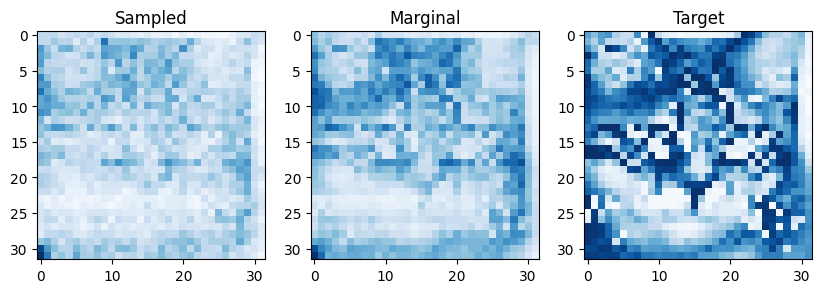

 40%|███▉      | 399/1000 [00:16<00:24, 24.26it/s]

loss = 0.16782982349395753
Reverse KL = 0.04408104717731476
Forward KL = 0.04012075066566467


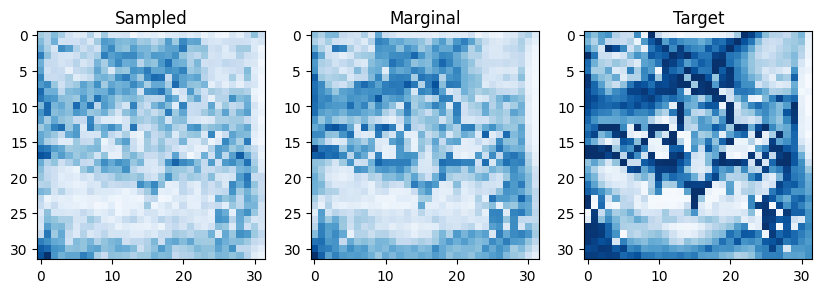

 50%|████▉     | 498/1000 [00:20<00:20, 24.51it/s]

loss = 0.07892298325896263
Reverse KL = 0.019680386409163475
Forward KL = 0.017638221383094788


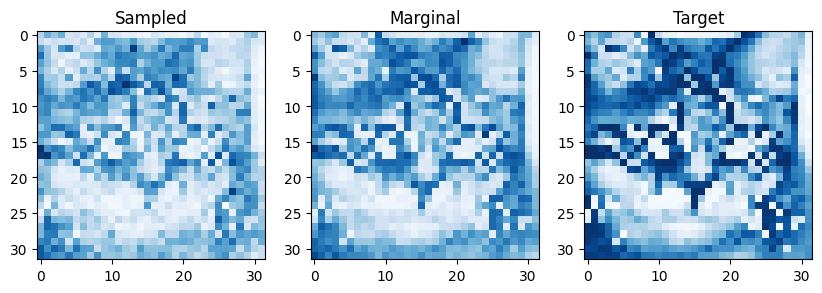

 60%|█████▉    | 597/1000 [00:25<00:16, 24.33it/s]

loss = 0.03828142547048628
Reverse KL = 0.009368512779474258
Forward KL = 0.00877631176263094


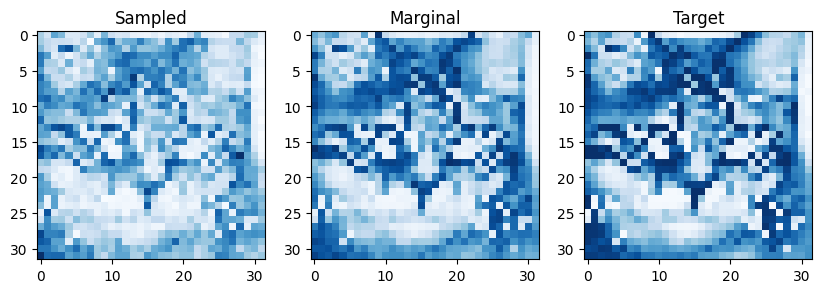

 70%|██████▉   | 699/1000 [00:29<00:12, 23.92it/s]

loss = 0.020440322179347277
Reverse KL = 0.005458800587803125
Forward KL = 0.004817408509552479


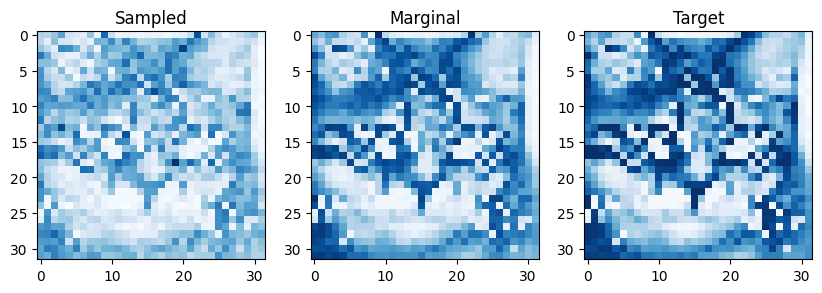

 80%|███████▉  | 798/1000 [00:34<00:08, 23.17it/s]

loss = 0.011752273766323923
Reverse KL = 0.002955926349386573
Forward KL = 0.0025530566927045584


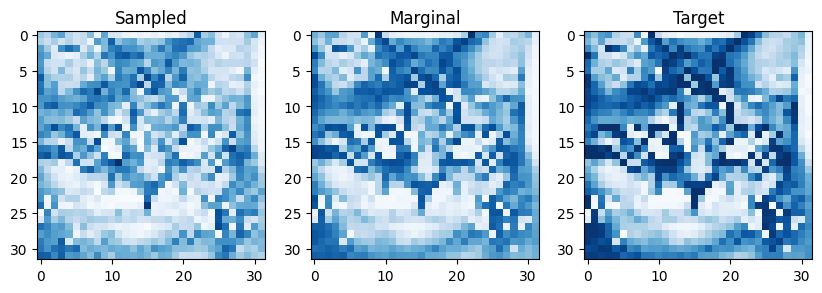

 90%|████████▉ | 897/1000 [00:38<00:04, 23.27it/s]

loss = 0.007310291146859526
Reverse KL = 0.002007465111091733
Forward KL = 0.0017649804940447211


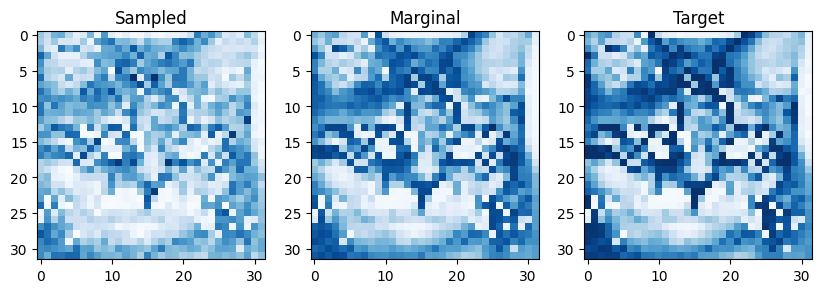

100%|█████████▉| 999/1000 [00:43<00:00, 22.72it/s]

loss = 0.004198713508667424
Reverse KL = 0.0013309493660926819
Forward KL = 0.001163853914476931


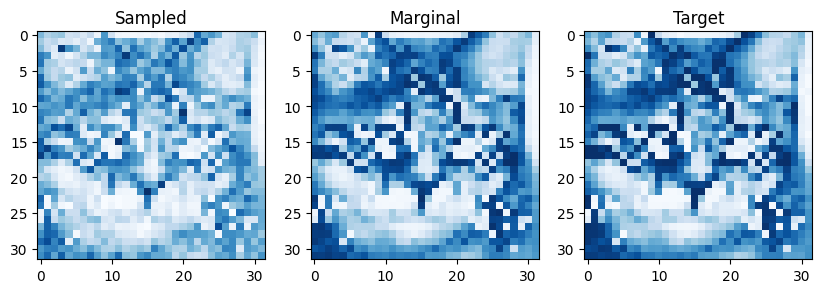

100%|██████████| 1000/1000 [00:43<00:00, 23.12it/s]


In [ ]:
losses = []
all_visited = []
resample = True
resample_every = 1

traj_len_history = []
weights_history = []

bs = 256
iter = 1000
T.set_grad_enabled(True)
for it in tqdm.trange(1, iter + 1):
    opt_resampled.zero_grad()
    
    z = T.zeros((bs, ndim), dtype=T.long).to(device)
    done = T.full((bs,), False, dtype=T.bool).to(device)
        
    action = None
    
    logf = T.zeros((ndim*horizon+1, bs)).to(device)
    logpf = T.zeros((ndim*horizon, bs)).to(device)
    logpb = T.zeros((ndim*horizon, bs)).to(device)
    
    i = 0
    while T.any(~done):
        
        pred = model_resampled(toin(z[~done]))
        
        edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # ended = (z[~done]==horizon-1).any(1).float()
        # ended_repeat = ended.unsqueeze(1).repeat(1,ndim)
        # edge_mask = T.cat([ ended_repeat, T.zeros(((~done).sum(),1), device=device) ], 1)

        logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        init_edge_mask = (z[~done]== 0).float()
        back_logits = ( (0 if uniform_pb else 1)*pred[...,ndim+1:2*ndim+1] - 1000000000*init_edge_mask).log_softmax(1)  # Need to check
        
        log_flow = pred[...,2*ndim+1]
        # if i>0 or detailed_balance: 
        #     logf[i,~done] = log_flow + log_reward(z[~done].float())  # DB with using reward information at every step
        # else: logf[i,~done] += Z
        logf[i,~done] = log_reward(z[~done].float()) - logits[:,ndim]
        
        if action is not None:
            logpb[i-1,~done] = back_logits.gather(1, action[action!=ndim].unsqueeze(1)).squeeze(1)

        # if resample and resample_every > 0 and i % resample_every == 0:
        #     cum_iw = - ( logf[0]+logpf.sum(0)-logf[i]-logpb.sum(0) )[~done]
        #     # weights = cum_iw.softmax(0).clamp(min=1./((~done).sum())**1.5)
        #     weights = cum_iw.softmax(0).clamp(max=1./((~done).sum())**1.5)
        #     sample = T.distributions.Categorical(weights).sample(((~done).sum(),))
        #     z[~done] = z[~done][sample]
        #     logf[:,~done] = logf[:,~done][:,sample]
        #     logpf[:,~done] = logpf[:,~done][:,sample]
        #     logpb[:,~done] = logpb[:,~done][:,sample]
        #     logits = logits[sample]

        # if T.all(done): break
        # # todo: avoid recomputing
        # pred = model_resampled(toin(z[~done]))
        # edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        exp_weight= 0.0
        temp = 1
        sample_ins_probs = (1-exp_weight)*(logits/temp).softmax(1) + exp_weight*(1-edge_mask) / (1-edge_mask+0.0000001).sum(1).unsqueeze(1)
        
        action = sample_ins_probs.multinomial(1)
        logpf[i,~done] = logits.gather(1, action).squeeze(1)

        with T.no_grad():
            terminate = (action==ndim).squeeze(1)

            done[~done] |= terminate
            logf[i+1:,done] = log_reward(z[done].float())  

        with T.no_grad():
            z[~done] = z[~done].scatter_add(1, action[~terminate], T.ones(action[~terminate].shape, dtype=T.long, device=device))

        
        i += 1

    for x in z:
        state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
        all_visited.append(state)

    # z_save = z.clone()
    # if resample:
    #     err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) )
    #     # iw = err
    #     iw =  err + (err**2).log()
    #     weights = iw.softmax(0)#.clamp(max=1./bs**1.5)
    #     sample = T.distributions.Categorical(weights).sample((bs,))
    #     z = z[sample]
    #     logf = logf[:,sample]
    #     logpf = logpf[:,sample]
    #     logpb = logpb[:,sample]
    
    if detailed_balance:
        lens = z.sum(1)+1
        loss = (logf[:-1]+logpf-logf[1:]-logpb).pow(2).sum()/lens.sum() 
    else:
        soft_temp = 1
        weights = T.ones(bs).to(device)
        if resample and i % resample_every == 0:
            err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) ).detach() / soft_temp
            weights = err.softmax(0) * bs

        loss = (weights * (logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0)).pow(2)).sum()/bs
        
    loss.backward()

    opt_resampled.step()

    losses.append(loss.item())

    if it%100==0: 
        print('loss =', np.array(losses[-100:]).mean())#, 'Z =', logf[0,0].item())
        emp_dist = np.bincount(all_visited[-100*bs:], minlength=len(true_dist)).astype(float)
        emp_dist /= emp_dist.sum()
        md = modeled_density(model_resampled).T
        mdsm = md.flatten().log().log_softmax(0)
        truesm = truelr.flatten().log_softmax(0)
        print('Reverse KL =', -(mdsm.exp() * (truesm-mdsm)).sum().item())
        print('Forward KL =', -(truesm.exp() * (mdsm-truesm)).sum().item())
        plt.figure(figsize=(10,3))
        plt.subplot(1,3,1);plt.title('Sampled')
        plt.imshow(emp_dist.reshape(horizon,horizon), cmap='Blues', vmin=0)
        plt.subplot(1,3,2);plt.title('Marginal')
        plt.imshow(md, cmap='Blues', vmin=0)
        plt.subplot(1,3,3);plt.title('Target')
        plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
        plt.show()

# Train with resampling with teacher reward

In [121]:
np.random.seed(0)
T.manual_seed(0)

Z_resampled2 = T.zeros((1,)).to(device)
if detailed_balance:
    model_resampled2 = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt_resampled2 = T.optim.Adam([ {'params':model_resampled2.parameters(), 'lr':0.001} ])
else:
    model_resampled2 = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt_resampled2 = T.optim.Adam([ {'params':model_resampled2.parameters(), 'lr':0.001}, {'params':[Z_resampled2], 'lr':0.1} ])
    Z_resampled2.requires_grad_()

 10%|▉         | 98/1000 [00:03<00:35, 25.30it/s]

loss = 0.013148340219631792
Reverse KL = 0.31706011295318604
Forward KL = 0.28977686166763306


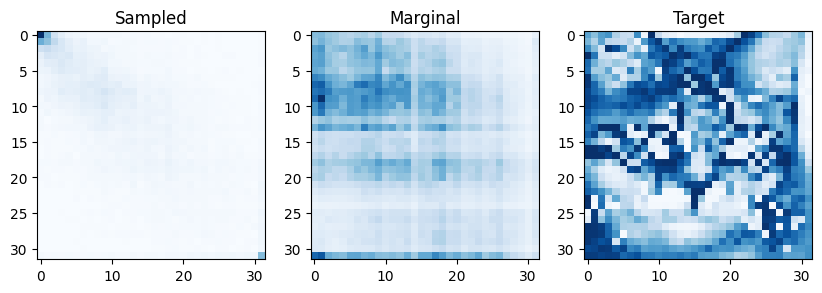

 20%|█▉        | 197/1000 [00:08<00:36, 22.01it/s]

loss = 0.0030379502440337092
Reverse KL = 0.16636504232883453
Forward KL = 0.15045706927776337


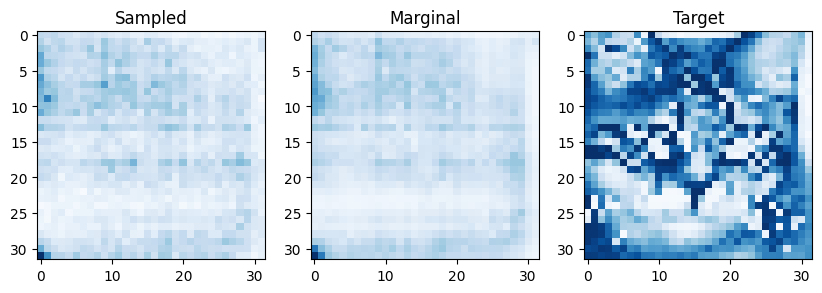

 30%|██▉       | 298/1000 [00:12<00:28, 24.39it/s]

loss = 0.0017730321042472496
Reverse KL = 0.1100853756070137
Forward KL = 0.10489737242460251


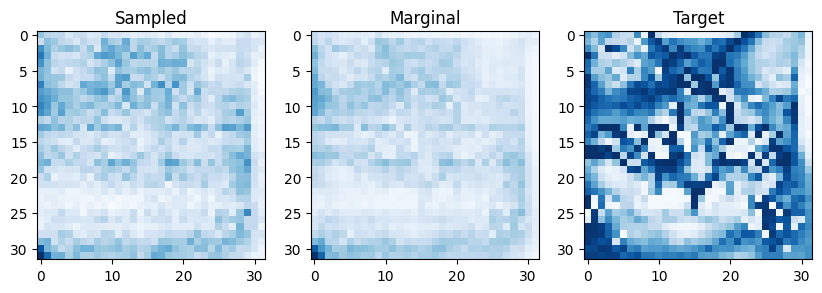

 40%|███▉      | 397/1000 [00:16<00:24, 25.02it/s]

loss = 0.0010639291812549346
Reverse KL = 0.05234486237168312
Forward KL = 0.052012160420417786


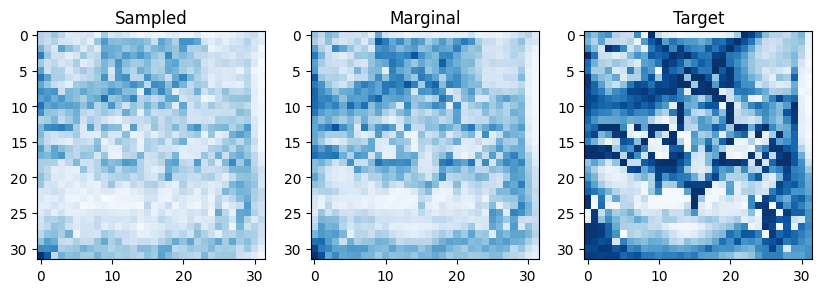

 50%|████▉     | 499/1000 [00:21<00:20, 24.23it/s]

loss = 0.0005265171229257248
Reverse KL = 0.024386929348111153
Forward KL = 0.02355033904314041


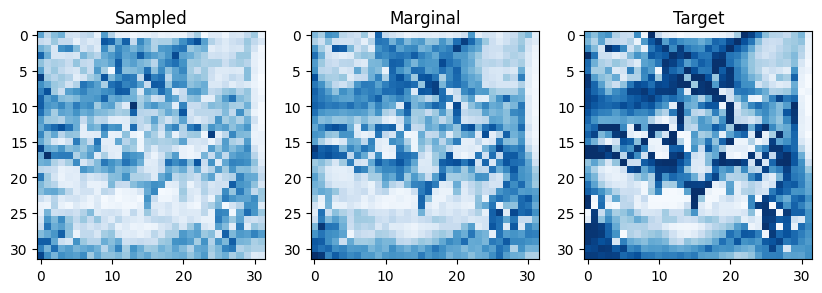

 60%|█████▉    | 598/1000 [00:25<00:18, 21.63it/s]

loss = 0.00025771104745217596
Reverse KL = 0.010553322732448578
Forward KL = 0.010026541538536549


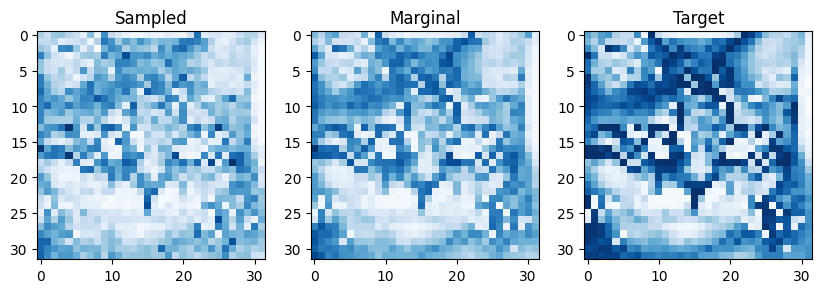

 70%|██████▉   | 697/1000 [00:31<00:13, 22.84it/s]

loss = 0.00012073040583345574
Reverse KL = 0.004418852273374796
Forward KL = 0.003966210875660181


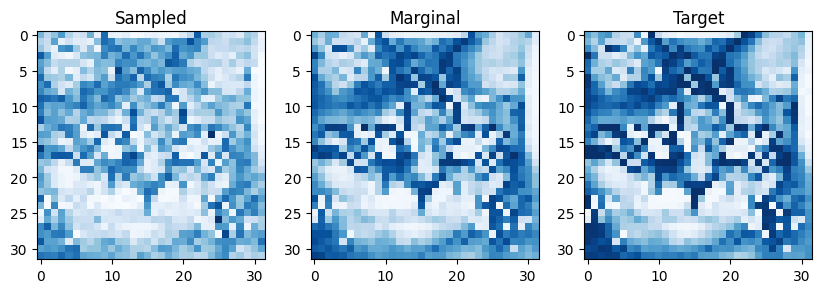

 80%|███████▉  | 797/1000 [00:36<00:11, 17.18it/s]

loss = 7.400104866974289e-05
Reverse KL = 0.002823063638061285
Forward KL = 0.002633331809192896


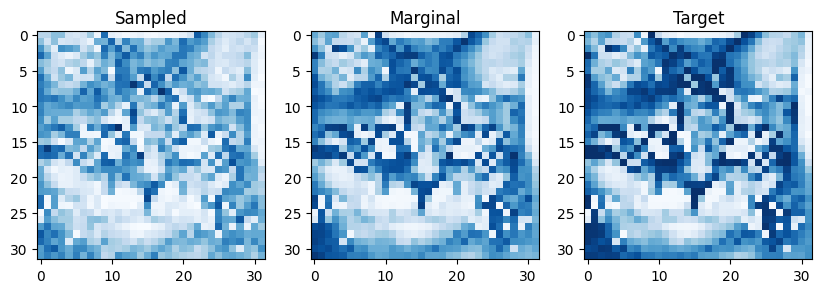

 90%|████████▉ | 898/1000 [00:42<00:04, 22.45it/s]

loss = 3.8072090783316524e-05
Reverse KL = 0.0013788691721856594
Forward KL = 0.0012992892879992723


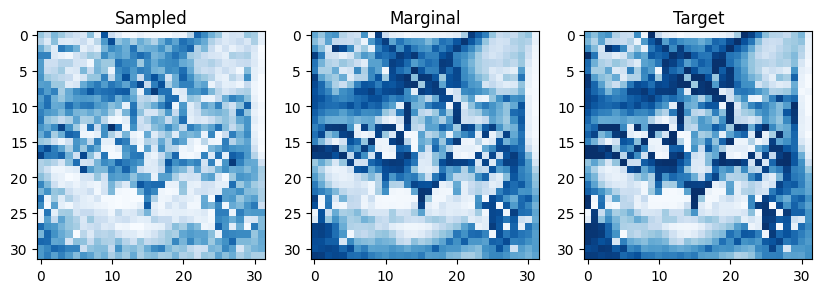

100%|█████████▉| 999/1000 [00:47<00:00, 14.92it/s]

loss = 2.4032473829720404e-05
Reverse KL = 0.000922319944947958
Forward KL = 0.0008111795759759843


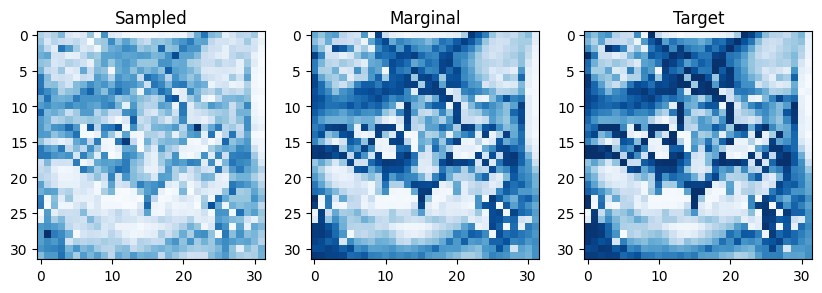

100%|██████████| 1000/1000 [00:47<00:00, 20.87it/s]


In [122]:
losses = []
all_visited = []
resample = True
resample_every = 1

traj_len_history = []
weights_history = []

bs = 256
iter = 1000
T.set_grad_enabled(True)
for it in tqdm.trange(1, iter + 1):
    opt_resampled2.zero_grad()
    
    z = T.zeros((bs, ndim), dtype=T.long).to(device)
    done = T.full((bs,), False, dtype=T.bool).to(device)
        
    action = None
    
    logf = T.zeros((ndim*horizon+1, bs)).to(device)
    logpf = T.zeros((ndim*horizon, bs)).to(device)
    logpb = T.zeros((ndim*horizon, bs)).to(device)
    
    i = 0
    while T.any(~done):
        
        pred = model_resampled2(toin(z[~done]))
        
        edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # ended = (z[~done]==horizon-1).any(1).float()
        # ended_repeat = ended.unsqueeze(1).repeat(1,ndim)
        # edge_mask = T.cat([ ended_repeat, T.zeros(((~done).sum(),1), device=device) ], 1)

        logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        init_edge_mask = (z[~done]== 0).float()
        back_logits = ( (0 if uniform_pb else 1)*pred[...,ndim+1:2*ndim+1] - 1000000000*init_edge_mask).log_softmax(1)  # Need to check
        
        log_flow = pred[...,2*ndim+1]
        # if i>0 or detailed_balance: 
        #     logf[i,~done] = log_flow + log_reward(z[~done].float())  # DB with using reward information at every step
        # else: logf[i,~done] += Z
        logf[i,~done] = log_reward(z[~done].float()) - logits[:,ndim]
        
        if action is not None:
            logpb[i-1,~done] = back_logits.gather(1, action[action!=ndim].unsqueeze(1)).squeeze(1)

        # if resample and resample_every > 0 and i % resample_every == 0:
        #     cum_iw = - ( logf[0]+logpf.sum(0)-logf[i]-logpb.sum(0) )[~done]
        #     # weights = cum_iw.softmax(0).clamp(min=1./((~done).sum())**1.5)
        #     weights = cum_iw.softmax(0).clamp(max=1./((~done).sum())**1.5)
        #     sample = T.distributions.Categorical(weights).sample(((~done).sum(),))
        #     z[~done] = z[~done][sample]
        #     logf[:,~done] = logf[:,~done][:,sample]
        #     logpf[:,~done] = logpf[:,~done][:,sample]
        #     logpb[:,~done] = logpb[:,~done][:,sample]
        #     logits = logits[sample]

        # if T.all(done): break
        # # todo: avoid recomputing
        # pred = model_resampled2(toin(z[~done]))
        # edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        exp_weight= 0.0
        temp = 1
        sample_ins_probs = (1-exp_weight)*(logits/temp).softmax(1) + exp_weight*(1-edge_mask) / (1-edge_mask+0.0000001).sum(1).unsqueeze(1)
        
        action = sample_ins_probs.multinomial(1)
        logpf[i,~done] = logits.gather(1, action).squeeze(1)

        with T.no_grad():
            terminate = (action==ndim).squeeze(1)

            done[~done] |= terminate
            logf[i+1:,done] = log_reward(z[done].float())  

        with T.no_grad():
            z[~done] = z[~done].scatter_add(1, action[~terminate], T.ones(action[~terminate].shape, dtype=T.long, device=device))

        
        i += 1

    for x in z:
        state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
        all_visited.append(state)

    # z_save = z.clone()
    # if resample:
    #     err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) )
    #     # iw = err
    #     iw =  err + (err**2).log()
    #     weights = iw.softmax(0)#.clamp(max=1./bs**1.5)
    #     sample = T.distributions.Categorical(weights).sample((bs,))
    #     z = z[sample]
    #     logf = logf[:,sample]
    #     logpf = logpf[:,sample]
    #     logpb = logpb[:,sample]
    
    if detailed_balance:
        lens = z.sum(1)+1
        loss = (logf[:-1]+logpf-logf[1:]-logpb).pow(2).sum()/lens.sum() 
    else:
        soft_temp = 10
        weights = T.ones(bs).to(device)
        if resample and i % resample_every == 0:
            err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) ).detach()
            weights = ((err ** 2).log() / soft_temp).softmax(0)

        loss = (weights * (logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0)).pow(2)).sum()/bs
        
    loss.backward()

    opt_resampled2.step()

    losses.append(loss.item())

    if it%100==0: 
        print('loss =', np.array(losses[-100:]).mean())#, 'Z =', logf[0,0].item())
        emp_dist = np.bincount(all_visited[-100*bs:], minlength=len(true_dist)).astype(float)
        emp_dist /= emp_dist.sum()
        md = modeled_density(model_resampled2).T
        mdsm = md.flatten().log().log_softmax(0)
        truesm = truelr.flatten().log_softmax(0)
        print('Reverse KL =', -(mdsm.exp() * (truesm-mdsm)).sum().item())
        print('Forward KL =', -(truesm.exp() * (mdsm-truesm)).sum().item())
        plt.figure(figsize=(10,3))
        plt.subplot(1,3,1);plt.title('Sampled')
        plt.imshow(emp_dist.reshape(horizon,horizon), cmap='Blues', vmin=0)
        plt.subplot(1,3,2);plt.title('Marginal')
        plt.imshow(md, cmap='Blues', vmin=0)
        plt.subplot(1,3,3);plt.title('Target')
        plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
        plt.show()